# Eksperimen Machine Learning - Titanic Dataset
**Nama:** Bayu Bimantara  
**Username Dicoding:** heesoonpark  
**Dataset:** Titanic Dataset (Kaggle)  
**Problem:** Binary Classification — Prediksi penumpang selamat atau tidak

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


## 1. Memuat Data

In [2]:
# Load dataset Titanic
df = sns.load_dataset('titanic')

print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"\nKolom-kolom  : {list(df.columns)}")
df.head()

Jumlah baris   : 891
Jumlah kolom   : 15

Kolom-kolom  : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Informasi dasar dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Statistik deskriptif
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per kolom:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Total missing values: 869


Distribusi kolom 'survived':
survived
0    549
1    342
Name: count, dtype: int64

Persentase selamat: 38.4%


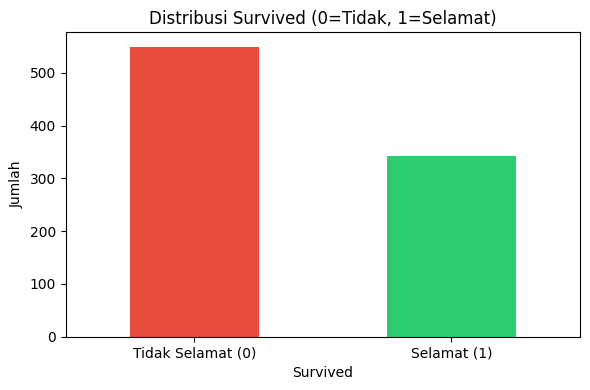

In [6]:
# Distribusi target: survived
print("Distribusi kolom 'survived':")
print(df['survived'].value_counts())
print(f"\nPersentase selamat: {df['survived'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
df['survived'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'], ax=ax)
ax.set_title('Distribusi Survived (0=Tidak, 1=Selamat)')
ax.set_xlabel('Survived')
ax.set_ylabel('Jumlah')
ax.set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'], rotation=0)
plt.tight_layout()
plt.show()

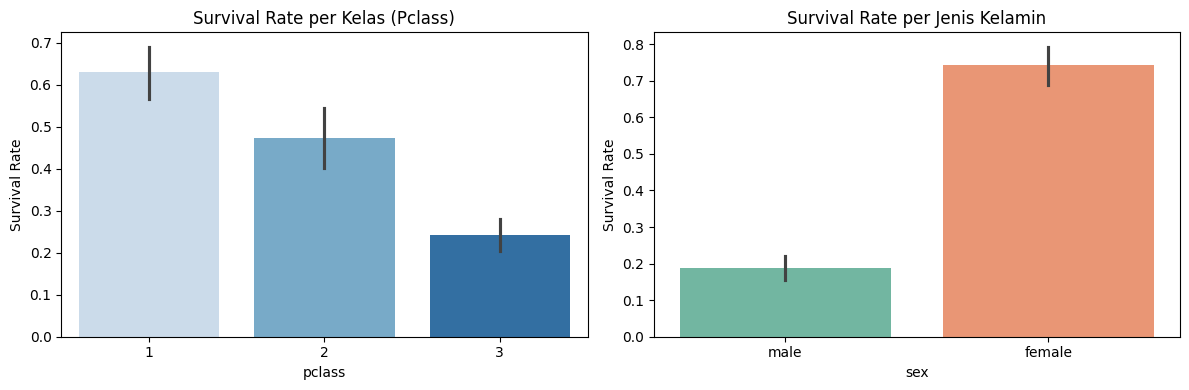

In [7]:
# Survival rate berdasarkan Pclass dan Sex
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival by Pclass
sns.barplot(data=df, x='pclass', y='survived', ax=axes[0], palette='Blues')
axes[0].set_title('Survival Rate per Kelas (Pclass)')
axes[0].set_ylabel('Survival Rate')

# Survival by Sex
sns.barplot(data=df, x='sex', y='survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate per Jenis Kelamin')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

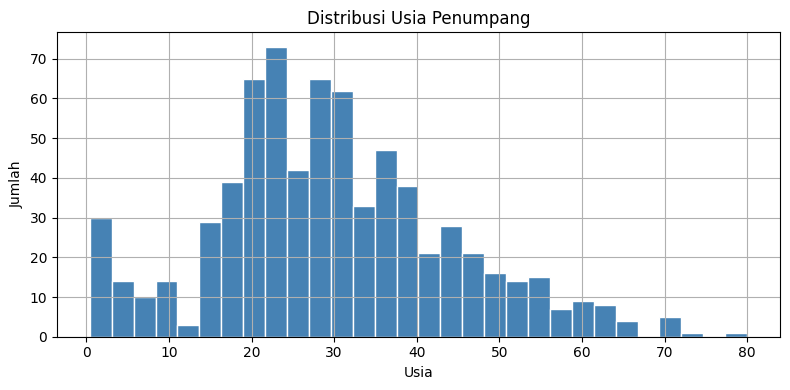

Rata-rata usia : 29.7 tahun
Median usia    : 28.0 tahun


In [8]:
# Distribusi kolom Age
fig, ax = plt.subplots(figsize=(8, 4))
df['age'].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribusi Usia Penumpang')
ax.set_xlabel('Usia')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

print(f"Rata-rata usia : {df['age'].mean():.1f} tahun")
print(f"Median usia    : {df['age'].median():.1f} tahun")

## 3. Preprocessing Data

In [9]:
# Pilih fitur yang relevan
kolom_fitur = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df_clean = df[kolom_fitur].copy()

print("Kolom yang digunakan:")
print(df_clean.dtypes)
print(f"\nShape: {df_clean.shape}")

Kolom yang digunakan:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

Shape: (891, 8)


In [10]:
# Handle missing values
# Age: isi dengan median
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

# Embarked: isi dengan modus
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

print("Missing values setelah preprocessing:")
print(df_clean.isnull().sum())

Missing values setelah preprocessing:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [11]:
# Label encoding untuk kolom kategorikal
le = LabelEncoder()

# Sex: male=1, female=0
df_clean['sex'] = le.fit_transform(df_clean['sex'])

# Embarked: C=0, Q=1, S=2
df_clean['embarked'] = le.fit_transform(df_clean['embarked'].astype(str))

print("Setelah encoding:")
print(df_clean.head())
print(f"\nTipe data:")
print(df_clean.dtypes)

Setelah encoding:
   pclass  sex   age  sibsp  parch     fare  embarked  survived
0       3    1  22.0      1      0   7.2500         2         0
1       1    0  38.0      1      0  71.2833         0         1
2       3    0  26.0      0      0   7.9250         2         1
3       1    0  35.0      1      0  53.1000         2         1
4       3    1  35.0      0      0   8.0500         2         0

Tipe data:
pclass        int64
sex           int64
age         float64
sibsp         int64
parch         int64
fare        float64
embarked      int64
survived      int64
dtype: object


In [12]:
# Rename kolom agar konsisten dengan huruf kapital
df_clean.rename(columns={
    'pclass': 'Pclass',
    'sex': 'Sex',
    'age': 'Age',
    'sibsp': 'SibSp',
    'parch': 'Parch',
    'fare': 'Fare',
    'embarked': 'Embarked',
    'survived': 'Survived'
}, inplace=True)

print("Dataset setelah rename kolom:")
print(df_clean.head())
print(f"\nShape: {df_clean.shape}")

Dataset setelah rename kolom:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Survived
0       3    1  22.0      1      0   7.2500         2         0
1       1    0  38.0      1      0  71.2833         0         1
2       3    0  26.0      0      0   7.9250         2         1
3       1    0  35.0      1      0  53.1000         2         1
4       3    1  35.0      0      0   8.0500         2         0

Shape: (891, 8)


## 4. Menyimpan Dataset yang Telah Dipreprocessing

In [13]:
# Split train/test
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Gabungkan kembali fitur dan target
train_df = X_train.copy()
train_df['Survived'] = y_train.values

test_df = X_test.copy()
test_df['Survived'] = y_test.values

print(f"Ukuran data training : {train_df.shape}")
print(f"Ukuran data testing  : {test_df.shape}")

Ukuran data training : (712, 8)
Ukuran data testing  : (179, 8)


In [14]:
# Simpan dataset yang sudah dipreprocessing
train_df.to_csv('titanic_preprocessing_train.csv', index=False)
test_df.to_csv('titanic_preprocessing_test.csv', index=False)

print("✅ Dataset berhasil disimpan!")
print("  → titanic_preprocessing_train.csv")
print("  → titanic_preprocessing_test.csv")

✅ Dataset berhasil disimpan!
  → titanic_preprocessing_train.csv
  → titanic_preprocessing_test.csv


In [15]:
# Verifikasi file tersimpan
import os
for fname in ['titanic_preprocessing_train.csv', 'titanic_preprocessing_test.csv']:
    size = os.path.getsize(fname)
    rows = pd.read_csv(fname).shape[0]
    print(f"✅ {fname} — {rows} baris, {size} bytes")
    
print("\nPreview train data:")
pd.read_csv('titanic_preprocessing_train.csv').head()

✅ titanic_preprocessing_train.csv — 712 baris, 16492 bytes
✅ titanic_preprocessing_test.csv — 179 baris, 4149 bytes

Preview train data:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,28.0,0,0,56.4958,2,1
1,2,1,28.0,0,0,0.0000,2,0
2,1,1,28.0,0,0,221.7792,2,0
3,3,0,18.0,0,1,9.3500,2,1
4,2,0,31.0,1,1,26.2500,2,1
